# Coreset Benchmarking — Apple Leaf Disease

This notebook benchmarks four coreset selection strategies on a local apple leaf disease dataset using ResNet50 embeddings.

**Methods evaluated:**
- Random
- KMeans
- KCenter (Greedy)
- HDBSCAN + KMeans (Medoids)

**Quality metrics:** Coverage@1 and Density@5

## 1. Imports

In [118]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from pathlib import Path
from PIL import Image
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
import hdbscan
import numpy as np
import random
import warnings
warnings.filterwarnings("ignore")

## 2. Configuration

In [ ]:
SEED         = 42
CORESET_SIZE = 50   # percentage of each class to keep in the coreset
IMG_SIZE     = (224, 224)   # images are resized to this before model upscaling

DATASET_ROOT = Path('~/Documents/computer_vision/coreset_selection/apple_dataset/train').expanduser()
SAVE_ROOT    = Path('../results_coreset_selection/coresets').expanduser()

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3. Data Loading — Local Folder Dataset

In [120]:
class_names = sorted([
    d.name for d in DATASET_ROOT.iterdir()
    if d.is_dir() and not d.name.startswith('.')
])
print(f"Found {len(class_names)} classes: {class_names}\n")

IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

def load_class_images(class_dir: Path, img_size=IMG_SIZE):
    """Load all images in a class folder as a float32 RGB array (N, H, W, 3)."""
    arrays, paths = [], []
    for p in sorted(class_dir.iterdir()):
        if p.suffix.lower() not in IMG_EXTENSIONS:
            continue
        try:
            img = Image.open(p).convert('RGB').resize(img_size, Image.BILINEAR)
            arrays.append(np.array(img, dtype=np.float32) / 255.0)
            paths.append(p)
        except Exception as e:
            print(f"  [skip] {p.name}: {e}")
    return np.stack(arrays), paths

# Load all classes
class_images = {}
class_paths  = {}

for cls in class_names:
    imgs, paths = load_class_images(DATASET_ROOT / cls)
    class_images[cls] = imgs
    class_paths[cls]  = paths
    print(f"  {cls}: {len(imgs)} images loaded — shape {imgs.shape[1:]}")

print(f"\nTotal images: {sum(len(v) for v in class_images.values())}")

Found 6 classes: ['apple_frogeye_leaf_spot', 'apple_leaf_healthy', 'apple_mosaic_leaf', 'apple_powdery_mildew_leaf', 'apple_rust_leaf', 'apple_scab_leaf']

  apple_frogeye_leaf_spot: 176 images loaded — shape (224, 224, 3)
  apple_leaf_healthy: 172 images loaded — shape (224, 224, 3)
  apple_mosaic_leaf: 175 images loaded — shape (224, 224, 3)
  apple_powdery_mildew_leaf: 175 images loaded — shape (224, 224, 3)
  apple_rust_leaf: 174 images loaded — shape (224, 224, 3)
  apple_scab_leaf: 171 images loaded — shape (224, 224, 3)

Total images: 1043


## 4. Feature Extractor — ResNet50 (upscaled to 224×224)


In [121]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input

class ResizeLayer(keras.layers.Layer):
    def __init__(self, target_size=(224, 224), **kwargs):
        super().__init__(**kwargs)
        self.target_size = target_size

    def call(self, x):
        return tf.image.resize(x, self.target_size)

    def get_config(self):
        return {**super().get_config(), 'target_size': self.target_size}


class PreprocessResNet(keras.layers.Layer):
    def call(self, x):
        return resnet_preprocess_input(x * 255.0)


class L2Normalize(keras.layers.Layer):
    def call(self, x):
        return tf.math.l2_normalize(x, axis=1)


def build_resnet50_extractor(input_hw=IMG_SIZE):
    bb = ResNet50(
        include_top=False,
        weights='imagenet',
        pooling='avg',
        input_shape=(224, 224, 3)
    )
    bb.trainable = False

    inp = keras.Input(shape=(*input_hw, 3))   # native resolution
    x   = ResizeLayer(target_size=(224, 224))(inp)
    x   = PreprocessResNet()(x)
    x   = bb(x, training=False)
    out = L2Normalize()(x)
    return Model(inp, out, name='resnet50_extractor')


resnet50_extractor = build_resnet50_extractor()
resnet50_extractor.summary()

Model: "resnet50_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resize_layer_6 (ResizeLayer)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_res_net_6            │ (None, 224, 224, 3)    │             0 │
│ (PreprocessResNet)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalize_6 (L2Normalize)    │ (None, 2048)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [122]:
def extract_embeddings(images, model, batch_size=32):
    embeddings = []
    for i in range(0, len(images), batch_size):
        embs = model.predict(images[i:i + batch_size], verbose=0)
        embeddings.append(embs)
    return np.vstack(embeddings) if embeddings else np.empty((0, 2048))  # 2048 for ResNet50

## 5. Per-Class Embedding Extraction

In [123]:
features_embs = {}

for cls in class_names:
    imgs = class_images[cls]
    print(f"Extracting embeddings: {cls} ({len(imgs)} images)...")
    embs = extract_embeddings(imgs, resnet50_extractor)
    features_embs[cls] = {
        'embeddings': embs,
        'image_paths': class_paths[cls]
    }

print("\nEmbedding extraction complete.")

Extracting embeddings: apple_frogeye_leaf_spot (176 images)...
Extracting embeddings: apple_leaf_healthy (172 images)...
Extracting embeddings: apple_mosaic_leaf (175 images)...
Extracting embeddings: apple_powdery_mildew_leaf (175 images)...
Extracting embeddings: apple_rust_leaf (174 images)...
Extracting embeddings: apple_scab_leaf (171 images)...

Embedding extraction complete.


## 6. Quality Metrics

### Coverage & Density

- **Coverage@k**: fraction of full-set points whose k-NN ball contains at least one coreset point.
- **Density@k**: average number of coreset points inside each full-set point's k-NN ball, normalized.

In [124]:
def coverage(full_embs, cs_embs, k=1):
    if len(cs_embs) == 0:
        return 0.0
    nn_f  = NearestNeighbors(n_neighbors=k + 1, metric='euclidean', n_jobs=-1).fit(full_embs)
    radii = nn_f.kneighbors(full_embs)[0][:, k]
    nn_c  = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1).fit(cs_embs)
    d_cs  = nn_c.kneighbors(full_embs)[0][:, 0]
    return float((d_cs <= radii).mean())

def density(full_embs, cs_embs, k=5, block_size=2000):
    S = len(cs_embs)
    if S == 0:
        return 0.0

    nn_f  = NearestNeighbors(n_neighbors=k + 1, metric='euclidean', n_jobs=-1).fit(full_embs)
    radii = nn_f.kneighbors(full_embs)[0][:, k]   # shape (|T|,)

    nn_c  = NearestNeighbors(metric='euclidean', n_jobs=-1).fit(cs_embs)
    count = 0
    for start in range(0, len(full_embs), block_size):
        block       = full_embs[start:start + block_size]
        block_radii = radii[start:start + block_size]
        results = nn_c.radius_neighbors(
            block, radius=float(block_radii.max()), return_distance=True
        )
        for i, dists in enumerate(results[0]):
            count += int((dists <= block_radii[i]).sum())

    return float(count / (k * S))


def get_coreset_target_size(features_dict, cls, percentage=CORESET_SIZE):
    """Return the number of samples to select for a given class."""
    return int(len(features_dict[cls]['embeddings']) * percentage / 100)

## 7. Coreset Selection Methods

### Method 1 — Random

In [125]:
def select_random(n_total, k, seed=SEED):
    """Select k indices uniformly at random without replacement."""
    return np.random.default_rng(seed).choice(n_total, size=k, replace=False)


coresets_random = {}
for cls in class_names:
    embs  = features_embs[cls]['embeddings']
    paths = features_embs[cls]['image_paths']
    k     = get_coreset_target_size(features_embs, cls)
    rel   = select_random(len(embs), k)
    coresets_random[cls] = {
        'coreset_indices': rel,
        'image_paths': [paths[i] for i in rel],
        'embeddings': embs[rel]
    }
    print(f"  {cls}: {k} images selected (Random)")

  apple_frogeye_leaf_spot: 88 images selected (Random)
  apple_leaf_healthy: 86 images selected (Random)
  apple_mosaic_leaf: 87 images selected (Random)
  apple_powdery_mildew_leaf: 87 images selected (Random)
  apple_rust_leaf: 87 images selected (Random)
  apple_scab_leaf: 85 images selected (Random)


### Method 2 — KMeans

In [126]:
def select_kmeans(embeddings, k, seed=SEED):
    """
    Select k representative samples via MiniBatchKMeans.
    One medoid (closest point to centroid) is picked per cluster.
    Shortfalls are filled with points closest to the global centroid.
    """
    k        = min(k, len(embeddings))
    km       = MiniBatchKMeans(
        n_clusters=k, random_state=seed, n_init=3, max_iter=100, batch_size=1024
    )
    labels   = km.fit_predict(embeddings)
    selected = []
    for c in range(k):
        idx_c = np.where(labels == c)[0]
        if len(idx_c) == 0:
            continue
        dists = np.sum((embeddings[idx_c] - km.cluster_centers_[c])**2, axis=1)
        selected.append(int(idx_c[np.argmin(dists)]))
    if len(selected) < k:
        pool = [i for i in range(len(embeddings)) if i not in set(selected)]
        gc_  = embeddings[selected].mean(axis=0)
        d    = np.sum((embeddings[pool] - gc_)**2, axis=1)
        selected += [pool[i] for i in np.argsort(d)[:k - len(selected)]]
    return selected


coresets_kmeans = {}
for cls in class_names:
    embs  = features_embs[cls]['embeddings']
    paths = features_embs[cls]['image_paths']
    k     = get_coreset_target_size(features_embs, cls)
    rel   = select_kmeans(embs, k)
    coresets_kmeans[cls] = {
        'coreset_indices': rel,
        'image_paths': [paths[i] for i in rel],
        'embeddings': embs[rel]
    }
    print(f"  {cls}: {len(rel)} images selected (KMeans)")

  apple_frogeye_leaf_spot: 88 images selected (KMeans)
  apple_leaf_healthy: 86 images selected (KMeans)
  apple_mosaic_leaf: 87 images selected (KMeans)
  apple_powdery_mildew_leaf: 87 images selected (KMeans)
  apple_rust_leaf: 87 images selected (KMeans)
  apple_scab_leaf: 85 images selected (KMeans)


### Method 3 — KCenter (Greedy)

In [127]:
def select_kcenter(embeddings, k, seed=SEED):
    """
    Greedy k-center algorithm (farthest-point sampling).
    Iteratively selects the point farthest from the current coreset.
    """
    N         = len(embeddings)
    k         = min(k, N)
    selected  = [random.Random(seed).randint(0, N - 1)]
    min_dists = np.full(N, np.inf)
    for _ in range(k - 1):
        d         = np.sum((embeddings - embeddings[selected[-1]])**2, axis=1)
        min_dists = np.minimum(min_dists, d)
        nxt       = int(np.argmax(min_dists))
        selected.append(nxt)
        min_dists[nxt] = 0
    return selected


coresets_kcenter = {}
for cls in class_names:
    embs  = features_embs[cls]['embeddings']
    paths = features_embs[cls]['image_paths']
    k     = get_coreset_target_size(features_embs, cls)
    rel   = select_kcenter(embs, k)
    coresets_kcenter[cls] = {
        'coreset_indices': rel,
        'image_paths': [paths[i] for i in rel],
        'embeddings': embs[rel]
    }
    print(f"  {cls}: {len(rel)} images selected (KCenter)")

  apple_frogeye_leaf_spot: 88 images selected (KCenter)
  apple_leaf_healthy: 86 images selected (KCenter)
  apple_mosaic_leaf: 87 images selected (KCenter)
  apple_powdery_mildew_leaf: 87 images selected (KCenter)
  apple_rust_leaf: 87 images selected (KCenter)
  apple_scab_leaf: 85 images selected (KCenter)


In [128]:
def hdbscan_budgets(labels, k, unique_clusters):
    """Compute per-cluster sampling budgets proportional to cluster size."""
    cluster_sizes   = {c: int(np.sum(labels == c)) for c in unique_clusters}
    total_clustered = sum(cluster_sizes.values())
    budgets         = {
        c: max(1, round(k * cluster_sizes[c] / total_clustered))
        for c in unique_clusters
    }
    # Fix rounding drift
    diff            = k - sum(budgets.values())
    sorted_clusters = sorted(unique_clusters, key=lambda c: cluster_sizes[c], reverse=True)
    n               = len(sorted_clusters)
    for i in range(abs(diff)):
        budgets[sorted_clusters[i % n]] += 1 if diff > 0 else -1
    return budgets

### Method 4 — HDBSCAN + KMeans (Medoids)

In [ ]:
def select_hdbscan_kmeans(embeddings, k, seed=SEED, noise_budget=0.05):
    """
    HDBSCAN clustering followed by KMeans-medoid selection within each cluster.
    A small fraction of the budget (noise_budget) is allocated to noise points.
    Returns: (selected_indices, n_clusters, n_noise)
    """
    N         = len(embeddings)
    k         = min(k, N)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=1, core_dist_n_jobs=-1)
    labels    = clusterer.fit_predict(embeddings)
    
    unique_clusters = [c for c in np.unique(labels) if c != -1]
    n_clusters      = len(unique_clusters)
    n_noise         = int(np.sum(labels == -1))
    
    rng             = np.random.default_rng(seed)
    selected        = []
    
    k_noise    = max(1, round(k * noise_budget)) if n_noise > 0 else 0
    k_clusters = k - k_noise
    budgets    = hdbscan_budgets(labels, k_clusters, unique_clusters)
    
    for c in unique_clusters:
        idx_c        = np.where(labels == c)[0]
        n_pick       = min(budgets[c], len(idx_c))
        cluster_embs = embeddings[idx_c]
        
        if n_pick == 1:
            center = cluster_embs.mean(axis=0)
            dists  = np.sum((cluster_embs - center)**2, axis=1)
            picked = idx_c[[np.argmin(dists)]]
        else:
            km        = MiniBatchKMeans(n_clusters=n_pick, random_state=seed, n_init=3, max_iter=100)
            km_labels = km.fit_predict(cluster_embs)
            picked_relative = []
            for sub_c in range(n_pick):
                sub_idx = np.where(km_labels == sub_c)[0]
                if len(sub_idx) == 0:
                    continue
                dists = np.sum(
                    (cluster_embs[sub_idx] - km.cluster_centers_[sub_c])**2, axis=1
                )
                picked_relative.append(int(sub_idx[np.argmin(dists)]))
            picked = idx_c[picked_relative]
            
        selected.extend(picked.tolist())
        
    if k_noise > 0 and n_noise > 0:
        noise_idx = np.where(labels == -1)[0]
        selected.extend(
            rng.choice(noise_idx, size=min(k_noise, len(noise_idx)), replace=False).tolist()
        )

    selected = list(dict.fromkeys(selected))
    missing = k - len(selected)
    
    if missing > 0:
        unselected = np.setdiff1d(np.arange(N), selected)
        fillers = rng.choice(unselected, size=min(missing, len(unselected)), replace=False)
        selected.extend(fillers.tolist())

    return selected[:k], n_clusters, n_noise

coresets_hdbscan_kmeans = {}
for cls in class_names:
    embs  = features_embs[cls]['embeddings']
    paths = features_embs[cls]['image_paths']
    k     = get_coreset_target_size(features_embs, cls)
    rel, n_clusters, n_noise = select_hdbscan_kmeans(embs, k)
    coresets_hdbscan_kmeans[cls] = {
        'coreset_indices': rel,
        'image_paths': [paths[i] for i in rel],
        'embeddings': embs[rel]
    }
    print(f"  {cls}: {len(rel)} images selected (HDBSCAN+KMeans) | clusters={n_clusters} | noise={n_noise}")

  apple_frogeye_leaf_spot: 88 images selected (HDBSCAN+KMeans) | clusters=4 | noise=24
  apple_leaf_healthy: 86 images selected (HDBSCAN+KMeans) | clusters=13 | noise=52
  apple_mosaic_leaf: 87 images selected (HDBSCAN+KMeans) | clusters=28 | noise=85
  apple_powdery_mildew_leaf: 87 images selected (HDBSCAN+KMeans) | clusters=2 | noise=13
  apple_rust_leaf: 87 images selected (HDBSCAN+KMeans) | clusters=9 | noise=24
  apple_scab_leaf: 85 images selected (HDBSCAN+KMeans) | clusters=17 | noise=63


## 8. Global Evaluation

Coverage@1 and Density@5 are computed on the concatenated embeddings of all classes.

In [130]:
all_full_embeddings = np.vstack([
    features_embs[cls]['embeddings'] for cls in class_names
])

print(f"Full embedding matrix shape: {all_full_embeddings.shape}")

results = []

print(f"\n{'Method':<25} {'Coverage@1':>12} {'Density@5':>12}")
print("─" * 52)

for name, coreset in [
    ('Random',              coresets_random),
    ('KMeans',              coresets_kmeans),
    ('KCenter',             coresets_kcenter),
    ('HDBSCAN+KMeans',      coresets_hdbscan_kmeans),
]:
    embs = np.vstack([coreset[cls]['embeddings'] for cls in class_names])
    cov  = coverage(all_full_embeddings, embs, k=1)
    den  = density(all_full_embeddings, embs, k=5)
    results.append({'Method': name, 'Coverage@1': cov, 'Density@5': den})
    print(f"{name:<25} {cov:.4f}        {den:.4f}")

Full embedding matrix shape: (1043, 2048)

Method                      Coverage@1    Density@5
────────────────────────────────────────────────────
Random                    0.7526        1.2231
KMeans                    0.7872        1.2373
KCenter                   0.5935        0.7538
HDBSCAN+KMeans            0.7967        1.2565


## 9. Save Coresets

In [131]:
def save_coreset(coreset_dict: dict, method_name: str, save_root: Path):
    """
    Copy selected images into save_root/method_name/<class>/<filename>.
    Also writes a CSV manifest: save_root/method_name/manifest.csv
    """
    import csv
    method_dir = save_root / method_name
    method_dir.mkdir(parents=True, exist_ok=True)

    manifest_rows = []

    for cls, data in coreset_dict.items():
        cls_dir = method_dir / cls
        cls_dir.mkdir(exist_ok=True)
        for src_path in data['image_paths']:
            dst = cls_dir / src_path.name
            shutil.copy2(src_path, dst)
            manifest_rows.append({'method': method_name, 'class': cls, 'filename': src_path.name,
                                  'src': str(src_path), 'dst': str(dst)})

    manifest_path = method_dir / 'manifest.csv'
    with open(manifest_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['method', 'class', 'filename', 'src', 'dst'])
        writer.writeheader()
        writer.writerows(manifest_rows)

    total = sum(len(v['image_paths']) for v in coreset_dict.values())
    print(f"  [{method_name}] {total} images saved → {method_dir}")
    print(f"           manifest → {manifest_path}")


print(f"Saving all coresets to: {SAVE_ROOT}\n")

for method_name, coreset in [
    ('random',         coresets_random),
    ('kmeans',         coresets_kmeans),
    ('kcenter',        coresets_kcenter),
    ('hdbscan_kmeans', coresets_hdbscan_kmeans),
]:
    save_coreset(coreset, method_name, SAVE_ROOT)

print("\nAll coresets saved.")

Saving all coresets to: output/coresets

  [random] 520 images saved → output/coresets/random
           manifest → output/coresets/random/manifest.csv
  [kmeans] 520 images saved → output/coresets/kmeans
           manifest → output/coresets/kmeans/manifest.csv
  [kcenter] 520 images saved → output/coresets/kcenter
           manifest → output/coresets/kcenter/manifest.csv
  [hdbscan_kmeans] 520 images saved → output/coresets/hdbscan_kmeans
           manifest → output/coresets/hdbscan_kmeans/manifest.csv

All coresets saved.


## 10. Results Summary

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame(results)

def highlight_max(col):
    return ['background-color: lightgreen' if v == col.max() else '' for v in col]

display(df.style.apply(highlight_max, subset=['Coverage@1', 'Density@5']))

,Method,Coverage@1,Density@5
0,Random,0.752637,1.223077
1,KMeans,0.787152,1.237308
2,KCenter,0.593480,0.753846
3,HDBSCAN+KMeans,0.796740,1.256538


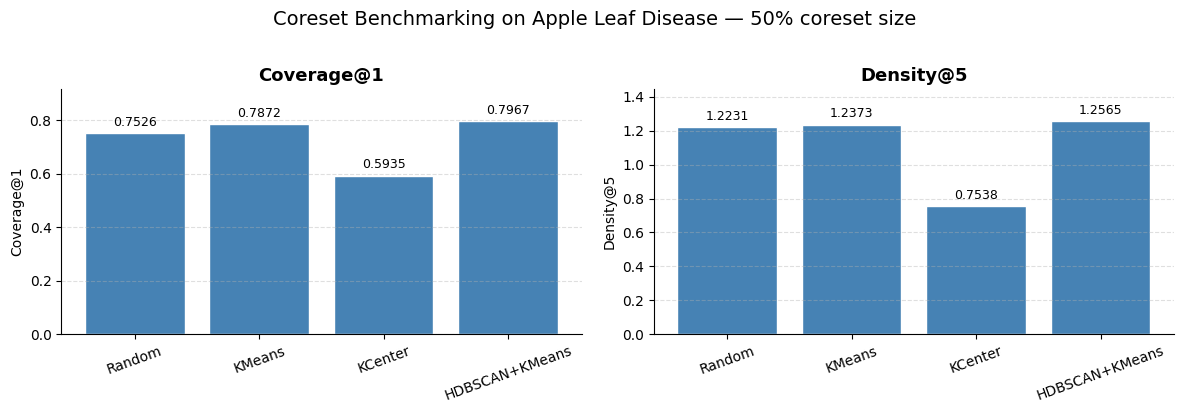

Plot saved to output/coreset_benchmark_results_apple.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ['Coverage@1', 'Density@5']):
    bars = ax.bar(df['Method'], df[metric], color='steelblue', edgecolor='white')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, df[metric].max() * 1.15)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    f'Coreset Benchmarking on Apple Leaf Disease — {CORESET_SIZE}% coreset size',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig('results_coreset_selection/coreset_benchmark_results_apple.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to results_coreset_selection/coreset_benchmark_results_apple.png")